# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [2]:
!cp "/content/drive/My Drive/aiml/GL/git/bangalore-feb-batch-smurli/R9/External-Lab/train_labels.csv" /content
!cp "/content/drive/My Drive/aiml/GL/git/bangalore-feb-batch-smurli/R9/External-Lab/images_racoon.rar" /content
!unrar x /content/images_racoon.rar


UNRAR 5.50 freeware      Copyright (c) 1993-2017 Alexander Roshal


Extracting from /content/images_racoon.rar

Creating    images                                                    OK
Creating    images/images                                             OK
Extracting  images/images/raccoon-1.jpg                                    0%  OK 
Extracting  images/images/raccoon-10.jpg                                   0%  OK 
Extracting  images/images/raccoon-100.jpg                                  0%  OK 
Extracting  images/images/raccoon-101.jpg                                  1%  OK 
Extracting  images/images/raccoon-102.jpg                                  1%  OK 
Extracting  images/images/raccoon-103.jpg                                  2%  OK 
Extracting  images/images/raccoon-104.jpg                                  2%  OK 
Extracting  images/images/raccoon-105.jpg                                  2%  OK 
Extra

### Import the necessary libraries

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf

### Change directory

In [4]:
cd /content/images

/content/images


### Load the training data from train.csv file

In [5]:
df = pd.read_csv("/content/train_labels.csv")
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


### Print the shape of the train dataset

In [6]:
df.shape

(173, 8)

In [7]:
df["class"].unique()

array(['raccoon'], dtype=object)

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
IMAGE_SIZE = 128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [0]:
import csv
pathList = []
coords = np.zeros(shape=(df.shape[0], 4))

with open('/content/train_labels.csv', newline='') as csvfile:
    csvreader = csv.reader(csvfile)
    next(csvreader, None)
    i=0
    for row in csvreader:
        (path,width,height,cls,x0,y0,x1,y1) = (row)
        pathList.append(path)
        img_width = int(width)
        img_height = int(height)
        
        xmin = int(x0) * IMAGE_SIZE/img_width
        xmax = int(x1) * IMAGE_SIZE/img_width

        ymin = int(y0) * IMAGE_SIZE/img_height
        ymax = int(y1) * IMAGE_SIZE/img_height

        #We will ask model to predict xmin, ymin, width and height of bounding box
        coords[i] = [xmin, ymin, xmax-xmin, ymax-ymin]
        i+=1

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [0]:
batch_images = np.zeros(shape=(df.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i in range(len(pathList)):
    img = tf.keras.preprocessing.image.load_img(pathList[i], target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    batch_images[i] = img_array

### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [11]:
tf.keras.backend.clear_session()

model = tf.keras.applications.mobilenet.MobileNet(include_top=False, #Do not include FC layer at the end
                                          input_shape=(IMAGE_SIZE,IMAGE_SIZE, 3),
                                          weights='imagenet')

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
17227776/17225924 [==============================] - 1s 0us/step


In [0]:
for layer in model.layers:
    layer.trainable = False

In [0]:
x = model.output

#Add one conv layer
x = tf.keras.layers.Conv2D(1024, (3,3))(x)

#Flatten the output to feed to Dense layer
x = tf.keras.layers.Flatten()(x)

#Add one Dense layer
x = tf.keras.layers.Dense(200, activation='relu')(x)

#Batch Norm
x = tf.keras.layers.BatchNormalization()(x)

bbox_output = tf.keras.layers.Dense(4 , activation='sigmoid', name='reg_op')(x)
final_model = tf.keras.models.Model(inputs=model.input, #Pre-trained model input as input layer
                                    outputs=[bbox_output]) #Output layer added


In [14]:
final_model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 128, 128, 3)]     0         
_________________________________________________________________
conv1_pad (ZeroPadding2D)    (None, 129, 129, 3)       0         
_________________________________________________________________
conv1 (Conv2D)               (None, 64, 64, 32)        864       
_________________________________________________________________
conv1_bn (BatchNormalization (None, 64, 64, 32)        128       
_________________________________________________________________
conv1_relu (ReLU)            (None, 64, 64, 32)        0         
_________________________________________________________________
conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)        288       
_________________________________________________________________
conv_dw_1_bn (BatchNormaliza (None, 64, 64, 32)        128   

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
from tensorflow.keras.backend import epsilon

def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [16]:
final_model.compile(optimizer='adam', loss='mse', metrics=[IoU])

Instructions for updating:
tf.py_func is deprecated in TF V2. Instead, there are two
    options available in V2.
    - tf.py_function takes a python function which manipulates tf eager
    tensors instead of numpy arrays. It's easy to convert a tf eager tensor to
    an ndarray (just call tensor.numpy()) but having access to eager tensors
    means `tf.py_function`s can use accelerators such as GPUs as well as
    being differentiable using a gradient tape.
    - tf.numpy_function maintains the semantics of the deprecated tf.py_func
    (it is not differentiable, and manipulates numpy arrays). It drops the
    stateful argument making all functions stateful.
    


In [0]:
def batch_generator(batch_images, coords, batch_size=32):
    while True:
        image_nums = np.random.randint(0,df.shape[0], size=batch_size)
        images = np.zeros(shape=(batch_size, IMAGE_SIZE, IMAGE_SIZE, 3))
        batch_bboxes = np.zeros(shape=(batch_size, 4))
        for i in range(batch_size):
            batch_bboxes[i] = coords[image_nums[i]]
            images[i] = batch_images[image_nums[i]]
        #images = tf.keras.applications.mobilenet.preprocess_input(images)
        batch_bboxes = batch_bboxes/IMAGE_SIZE
        yield images, batch_bboxes

In [0]:
batchsize = 32
train_generator = batch_generator(batch_images, coords, batch_size=batchsize)

In [19]:
final_model.fit_generator(train_generator, 
                          epochs=30,
                          steps_per_epoch= df.shape[0]//batchsize)

Epoch 1/30
5/5 [==============================] - 5s 1s/step - loss: 0.1827 - IoU: 0.1902
Epoch 2/30
5/5 [==============================] - 0s 60ms/step - loss: 0.1181 - IoU: 0.2928
Epoch 3/30
5/5 [==============================] - 0s 58ms/step - loss: 0.0961 - IoU: 0.3328
Epoch 4/30
5/5 [==============================] - 0s 56ms/step - loss: 0.0669 - IoU: 0.3793
Epoch 5/30
5/5 [==============================] - 0s 55ms/step - loss: 0.0705 - IoU: 0.4297
Epoch 6/30
5/5 [==============================] - 0s 56ms/step - loss: 0.0669 - IoU: 0.4005
Epoch 7/30
5/5 [==============================] - 0s 54ms/step - loss: 0.0646 - IoU: 0.3775
Epoch 8/30
5/5 [==============================] - 0s 56ms/step - loss: 0.0540 - IoU: 0.4825
Epoch 9/30
5/5 [==============================] - 0s 56ms/step - loss: 0.0479 - IoU: 0.4729
Epoch 10/30
5/5 [==============================] - 0s 54ms/step - loss: 0.0488 - IoU: 0.4481
Epoch 11/30
5/5 [==============================] - 0s 56ms/step - loss: 0.0432 - 

### Pick a test image from the given data

In [21]:
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,raccoon-17.jpg,259,194,raccoon,95,60,167,118
1,raccoon-11.jpg,660,432,raccoon,3,1,461,431
2,raccoon-63.jpg,600,400,raccoon,74,107,280,290
3,raccoon-63.jpg,600,400,raccoon,227,93,403,298
4,raccoon-60.jpg,273,185,raccoon,58,33,197,127


In [0]:
image_num = 30
img = tf.keras.preprocessing.image.load_img(df.loc[image_num, 'filename'])
w, h = img.size

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

In [0]:
img_resized = img.resize((IMAGE_SIZE, IMAGE_SIZE)) 

### Predict the coordinates of the bounding box for the given test image

In [0]:
input_array = tf.keras.preprocessing.image.img_to_array(img_resized)
input_array = np.expand_dims(input_array, axis=0)
input_array = tf.keras.applications.resnet50.preprocess_input(input_array)

pred = final_model.predict(input_array)

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

In [0]:
(filename,image_width,image_height,cls,xmin,ymin,xmax,ymax) = df.iloc[image_num].values

img = tf.keras.preprocessing.image.load_img(filename)
unscaled = img
region = pred[0]
region = region * IMAGE_SIZE

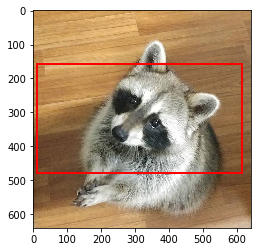

In [88]:
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()